# RMVP, one step at a time — and what MVP does at each one

`RMVP` is `MVP` with **one thing changed**. This notebook goes through that change in nine steps,
and at every step it shows what MVP does first, so the difference is always visible rather than
asserted.

The short version, which will make more sense once you have been through step 1:

> The miss distance depends on the **direction** of the relative velocity and on nothing else about
> it. So navigation uncertainty is, for this problem, an uncertainty about an **angle**. MVP treats
> that angle as exact. RMVP asks for enough angular margin to cover it — and the manoeuvre that
> supplies the margin also shrinks it, which is why the rule is a fixed point rather than a formula.

| step | question | MVP's answer | RMVP's answer |
|---|---|---|---|
| 1 | what is the miss distance? | $\lvert\mathbf r\rvert\sin\alpha$ | same |
| 2 | when is it a conflict? | $\alpha<\gamma$ | same |
| 3 | what is the manoeuvre? | rotate by $\gamma-\alpha$ | rotate by more |
| 4 | how well is $\alpha$ known? | *not asked* | $\sigma_\varphi=\sigma_v/\lvert\mathbf v\rvert$ |
| 5 | how well is the margin known? | *not asked* | $\sigma_m$ |
| 6 | does the manoeuvre change that? | *not asked* | yes, $\sigma_m(\theta)$ |
| 7 | so how far to rotate? | $\gamma-\alpha$ | solve $\alpha+\theta-\gamma=k\sigma_m(\theta)$ |
| 8 | what does the code look like? | — | MVP plus five lines |
| 9 | does it work? | — | measured, including where it does not |

Everything is computed live from `opencdarr` and from `robust-mvp/rmvp.py`. Nothing below is a
quoted number.

In [1]:
%matplotlib inline
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path.cwd() if Path.cwd().name == "robust-mvp" else Path.cwd() / "robust-mvp"))
plt.rcParams["figure.dpi"] = 130

from opencdarr.cns import GnssNavigation
from opencdarr.cns.noise_distributions import CI95_TO_SIGMA
from opencdarr.cr import MVP
from opencdarr.relative import relative_enu, velocity_enu
from opencdarr.scenario import create_conflict
from opencdarr.state import AircraftState

from rmvp import RMVP, angular_sigma, relative_sigmas, rotation

GREY, RED, BLUE, ORANGE = "0.45", "#d62728", "#1f77b4", "#ff7f0e"

SPEED = 10.2889   # m/s = 20 kt, both aircraft
RPZ = 50.0        # m, protected zone
MARGIN = 1.05     # the resolvers' fixed buffer, so they aim at 52.5 m
TLOS = 180.0      # s to loss of separation at spawn
POS_CI95, VEL_CI95 = 10.0, 3.0   # what each aircraft declares about itself


def encounter(dpsi, pos_ci95=POS_CI95, vel_ci95=VEL_CI95, dcpa=0.0):
    """One head-on-ish crossing at `dpsi` degrees, both aircraft at 20 kt."""
    own = AircraftState(id="OWN", lat=52.0, lon=4.0, trk=0.0, gs=SPEED,
                        pos_ci95=pos_ci95, vel_ci95=vel_ci95)
    intr = create_conflict(own, intr_id="INT", dpsi=dpsi, dcpa=dcpa,
                           tlos=TLOS, rpz=RPZ, side=1)
    return own, intr


own2, intr2 = encounter(2.0)      # the fragile geometry
own30, intr30 = encounter(30.0)   # the comfortable one

for name, (o, i) in (("2 deg", (own2, intr2)), ("30 deg", (own30, intr30))):
    rel = relative_enu(o, i)
    print(f"{name:>7}: range {rel.dist:8.1f} m   |v_rel| {math.hypot(rel.vx, rel.vy):6.3f} m/s")

  2 deg: range    114.6 m   |v_rel|  0.359 m/s
 30 deg: range   1008.7 m   |v_rel|  5.326 m/s


---
## Step 1 — the miss distance is an angle in disguise

Write $\mathbf r$ for the relative position (intruder minus ownship) and $\mathbf v$ for the
relative velocity. The predicted closest-approach offset is

$$ d \;=\; \frac{\lvert\mathbf r\times\mathbf v\rvert}{\lvert\mathbf v\rvert} $$

Now let $\alpha$ be the angle between $\mathbf v$ and the line of sight. Then

$$ \boxed{\,d = \lvert\mathbf r\rvert\sin\alpha\,} \qquad\text{and}\qquad t_\text{CPA} = \frac{\lvert\mathbf r\rvert\cos\alpha}{\lvert\mathbf v\rvert} $$

Read the boxed line carefully, because the whole method is in it. **$d$ does not depend on
$\lvert\mathbf v\rvert$ at all.** Doubling the relative speed changes when you get there, not how
close you come. Only the *direction* of $\mathbf v$ matters.

**What MVP does here:** exactly the same thing, written differently. MVP forms
$\mathbf c=\mathbf r+\mathbf v\,t_\text{CPA}$ and takes $d_m=\lvert\mathbf c\rvert$. That is the
same number — let us check rather than trust.

In [2]:
def geometry(own, intr):
    """The three numbers every step below is built from: range, |v_rel|, and the angle alpha."""
    rel = relative_enu(own, intr)
    v_mag = math.hypot(rel.vx, rel.vy)
    t_cpa = -(rel.rx * rel.vx + rel.ry * rel.vy) / v_mag**2
    c = (rel.rx + rel.vx * t_cpa, rel.ry + rel.vy * t_cpa)   # MVP's own CPA vector
    d_mvp = math.hypot(*c)                                    # MVP's d_miss
    cross = abs(rel.rx * rel.vy - rel.ry * rel.vx) / v_mag    # |r x v| / |v|
    alpha = math.asin(min(cross / rel.dist, 1.0))
    return rel, v_mag, t_cpa, d_mvp, cross, alpha


rel, v_mag, t_cpa, d_mvp, cross, alpha = geometry(*encounter(40.0, dcpa=30.0))
print(f"MVP's  |c|            = {d_mvp:.9f} m")
print(f"|r x v| / |v|         = {cross:.9f} m")
print(f"|r| sin(alpha)        = {rel.dist * math.sin(alpha):.9f} m")
print(f"t_cpa from MVP        = {t_cpa:.6f} s")
print(f"|r| cos(alpha) / |v|  = {rel.dist * math.cos(alpha) / v_mag:.6f} s")

MVP's  |c|            = 30.000000000 m
|r x v| / |v|         = 30.000000000 m
|r| sin(alpha)        = 30.000000000 m
t_cpa from MVP        = 185.683415 s
|r| cos(alpha) / |v|  = 185.683415 s


Three ways of writing one number. Now the claim that matters — scale the relative speed and watch
the miss distance not move, then rotate it by one degree and watch it move a lot.

In [3]:
rel, v_mag, *_ , alpha = geometry(*encounter(40.0, dcpa=30.0))
r_vec = np.array([rel.rx, rel.ry])
v_hat = np.array([rel.vx, rel.vy]) / v_mag


def miss(v):
    """d = |r x v| / |v| for any relative velocity v."""
    return abs(r_vec[0] * v[1] - r_vec[1] * v[0]) / np.hypot(*v)


print("scaling |v_rel|  (direction fixed)")
for k in (0.25, 1.0, 4.0, 40.0):
    print(f"   |v| x {k:5.2f}  ->  d = {miss(k * v_mag * v_hat):8.3f} m")

print("\nrotating v_rel by one degree (magnitude fixed)")
for deg in (-1.0, 0.0, 1.0, 2.0):
    a = math.radians(deg)
    rot = np.array([v_hat[0] * math.cos(a) - v_hat[1] * math.sin(a),
                    v_hat[0] * math.sin(a) + v_hat[1] * math.cos(a)])
    print(f"   {deg:+5.1f} deg  ->  d = {miss(v_mag * rot):8.3f} m")

scaling |v_rel|  (direction fixed)
   |v| x  0.25  ->  d =   30.000 m
   |v| x  1.00  ->  d =   30.000 m
   |v| x  4.00  ->  d =   30.000 m
   |v| x 40.00  ->  d =   30.000 m

rotating v_rel by one degree (magnitude fixed)
    -1.0 deg  ->  d =    7.188 m
    +0.0 deg  ->  d =   30.000 m
    +1.0 deg  ->  d =   52.803 m
    +2.0 deg  ->  d =   75.590 m


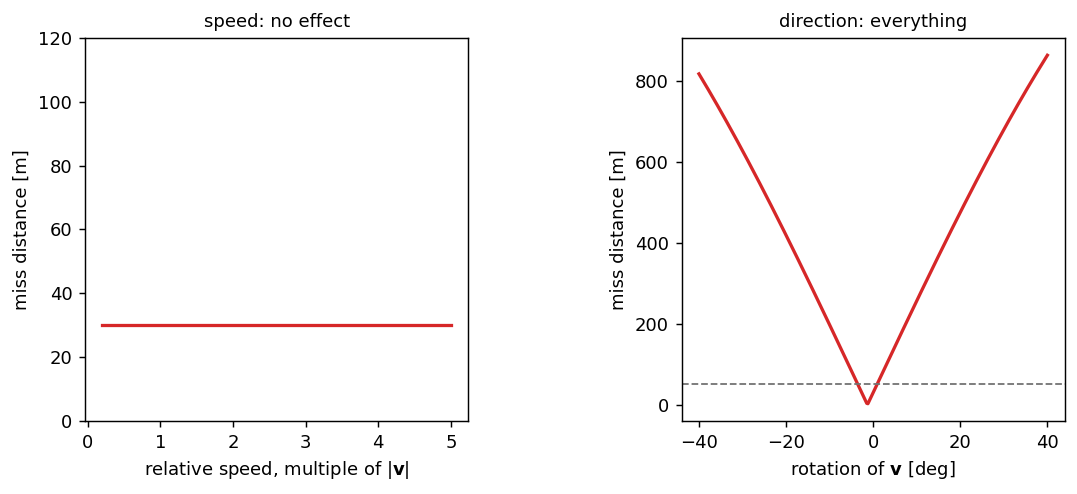

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 3.9))

scales = np.linspace(0.2, 5.0, 200)
ax1.plot(scales, [miss(s * v_mag * v_hat) for s in scales], color=RED, lw=1.8)
ax1.set_xlabel(r"relative speed, multiple of $|\mathbf{v}|$")
ax1.set_ylabel("miss distance [m]")
ax1.set_ylim(0, 120)
ax1.set_title("speed: no effect", fontsize=10)
ax1.set_box_aspect(1)

degs = np.linspace(-40, 40, 300)
ds = []
for deg in degs:
    a = math.radians(deg)
    rot = np.array([v_hat[0] * math.cos(a) - v_hat[1] * math.sin(a),
                    v_hat[0] * math.sin(a) + v_hat[1] * math.cos(a)])
    ds.append(miss(v_mag * rot))
ax2.plot(degs, ds, color=RED, lw=1.8)
ax2.axhline(RPZ, color=GREY, ls="--", lw=1.0)
ax2.set_xlabel("rotation of $\\mathbf{v}$ [deg]")
ax2.set_ylabel("miss distance [m]")
ax2.set_title("direction: everything", fontsize=10)
ax2.set_box_aspect(1)
fig.tight_layout()

**Take-away.** A conflict-resolution problem that looks two-dimensional (a velocity vector) is
one-dimensional (its direction). Every step below lives on that one axis.

The dashed line on the right is the protected zone. Notice it cuts the curve at two angles — those
two crossings are the velocity obstacle's legs, and we never had to construct a cone to find them.

---
## Step 2 — the conflict test is a comparison of two angles

Define $\gamma$ as the angle at which the miss distance is exactly the resolution zone
$R=\texttt{margin}\times\texttt{rpz}$:

$$ R = \lvert\mathbf r\rvert\sin\gamma \quad\Longrightarrow\quad \gamma=\arcsin\frac{R}{\lvert\mathbf r\rvert} $$

Since $\sin$ is increasing on $[0,\pi/2]$,

$$ d < R \iff \sin\alpha<\sin\gamma \iff \alpha<\gamma $$

$\gamma$ is the **half-angle of the velocity obstacle**. We get it from one `arcsin`, and the
conflict test is one comparison.

**What MVP does here:** the same two `arcsin` calls, inside its `erratum` term —
`math.asin(rpz_eff / dist)` and `math.asin(d_miss / dist)` are $\gamma$ and $\alpha$. MVP already
computes both angles; it just never names them.

In [5]:
for label, (o, i) in (("2 deg", (own2, intr2)), ("30 deg", (own30, intr30))):
    rel, v_mag, t_cpa, d_mvp, cross, alpha = geometry(o, i)
    gamma = math.asin(RPZ * MARGIN / rel.dist)
    print(f"{label:>7}: range {rel.dist:7.1f} m | alpha {math.degrees(alpha):6.3f} deg "
          f"| gamma {math.degrees(gamma):6.2f} deg | conflict {alpha < gamma}")

  2 deg: range   114.6 m | alpha  0.000 deg | gamma  27.25 deg | conflict True
 30 deg: range  1008.7 m | alpha  0.000 deg | gamma   2.98 deg | conflict True


At `dcpa` = 0 the true miss distance is zero, so $\alpha\approx0$: the relative velocity points
straight down the line of sight. Both geometries are in conflict, and the 2° case has a much wider
obstacle (25.9° against 2.8°) simply because the aircraft are closer when they notice.

---
## Step 3 — MVP is exactly a rotation

MVP's step is along $\hat{\mathbf c}$, and $\mathbf c\cdot\mathbf v=\mathbf r\cdot\mathbf v+
\lvert\mathbf v\rvert^2t_\text{CPA}=0$, so **the step is perpendicular to $\mathbf v$**. A
perpendicular step of size $a$ therefore rotates the relative velocity and lengthens it:

$$ \theta=\arctan\frac{a}{\lvert\mathbf v\rvert}, \qquad \lvert\mathbf v'\rvert=\frac{\lvert\mathbf v\rvert}{\cos\theta} $$

Substituting into MVP's own gain formula and using
$\sin\gamma=\sin(\gamma-\alpha)\cos\alpha+\cos(\gamma-\alpha)\sin\alpha$:

$$ \lVert\Delta\mathbf v\rVert_\text{MVP}=\frac{\text{gain}}{\lvert t_\text{CPA}\rvert} = \frac{\lvert\mathbf v\rvert}{\cos\alpha}\left(\frac{\sin\gamma}{\cos(\gamma-\alpha)}-\sin\alpha\right) = \boxed{\lvert\mathbf v\rvert\tan(\gamma-\alpha)} $$

**MVP rotates the relative velocity by exactly $\gamma-\alpha$** — onto the obstacle's leg, no
overshoot. That is the sentence the whole method hangs on, so let us check it against the shipped
code.

In [6]:
def mvp_step(own, intr):
    """||dv|| the shipped MVP actually commands."""
    ve, vn = velocity_enu(own)
    ne, nn = MVP(margin=MARGIN).resolve(own, [intr], RPZ).target_velocity
    return math.hypot(ne - ve, nn - vn)


print(f"{'dpsi':>6} {'MVP (erratum form)':>20} {'|v| tan(gamma-alpha)':>22} {'rel. diff':>12}")
for dpsi in (2.0, 10.0, 30.0, 90.0):
    o, i = encounter(dpsi)
    rel, v_mag, t_cpa, d_mvp, cross, alpha = geometry(o, i)
    # MVP floors a vanishing miss distance at 0.1 m before taking its direction, so use that alpha
    alpha_floored = math.asin(max(d_mvp, 0.1) / rel.dist)
    gamma = math.asin(RPZ * MARGIN / rel.dist)
    angle_form = v_mag * math.tan(gamma - alpha_floored)
    shipped = mvp_step(o, i)
    print(f"{dpsi:6.0f} {shipped:20.9f} {angle_form:22.9f} {abs(shipped-angle_form)/shipped:12.2e}")

  dpsi   MVP (erratum form)   |v| tan(gamma-alpha)    rel. diff
     2          0.184602819            0.184602889     3.80e-07
    10          0.254601981            0.254601990     3.60e-08
    30          0.277055444            0.277055446     4.91e-09
    90          0.285712977            0.285712977     7.02e-10


Agreement to about $10^{-7}$ relative, which is float64 round-off between two algebraically
identical expressions, not a modelling gap (`verify_rmvp.py` checks the same identity at 25 digits
with `mpmath`).

**Why this matters for what follows.** Because MVP *is* a rotation, we can change how far it rotates
without touching anything else — not the direction, not the tie-break at a head-on, not the sum over
intruders. RMVP changes one number: $\theta$.

---
## Step 4 — how well is that angle actually known?

This is the first question MVP never asks.

The aircraft do not know $\mathbf v$; they know a *perceived* $\tilde{\mathbf v}=\mathbf v+
\mathbf e_v$. A velocity error $\mathbf e_v$ perpendicular to $\mathbf v$ rotates it by

$$ \delta\varphi_v=\frac{\mathbf e_v\cdot\hat{\mathbf n}}{\lvert\mathbf v\rvert} \qquad\Longrightarrow\qquad \boxed{\sigma_\varphi=\frac{\sigma_v}{\lvert\mathbf v\rvert}} $$

An **angular signal-to-noise ratio**. It is large exactly when the relative speed is small — which
is what a shallow crossing between same-speed aircraft *is*.

In [7]:
sigma_r, sigma_v = relative_sigmas(own2, intr2)   # per-axis, both aircraft summed
print(f"declared pos_ci95 {POS_CI95:g} m, vel_ci95 {VEL_CI95:g} m/s")
print(f"  -> relative sigma_r = {sigma_r:.4f} m,  sigma_v = {sigma_v:.4f} m/s\n")

for label, (o, i) in (("2 deg", (own2, intr2)), ("30 deg", (own30, intr30))):
    rel, v_mag, *_ = geometry(o, i)
    print(f"{label:>7}: |v_rel| {v_mag:6.3f} m/s   sigma_phi = sigma_v/|v| = "
          f"{sigma_v / v_mag:6.3f} rad  ({math.degrees(sigma_v / v_mag):7.1f} deg)")

declared pos_ci95 10 m, vel_ci95 3 m/s
  -> relative sigma_r = 5.7776 m,  sigma_v = 1.7333 m/s

  2 deg: |v_rel|  0.359 m/s   sigma_phi = sigma_v/|v| =  4.826 rad  (  276.5 deg)
 30 deg: |v_rel|  5.326 m/s   sigma_phi = sigma_v/|v| =  0.325 rad  (   18.6 deg)


**4.83 radians.** That is 277°, on a quantity that only spans 360°. At a 2° crossing the direction
of the relative velocity is not noisy — it is *unknown*. At 30° it is 18.6°, uncomfortable but
usable.

Let us see it rather than take the number on faith: perceive the same encounter 4000 times and
histogram the perceived $\alpha$.

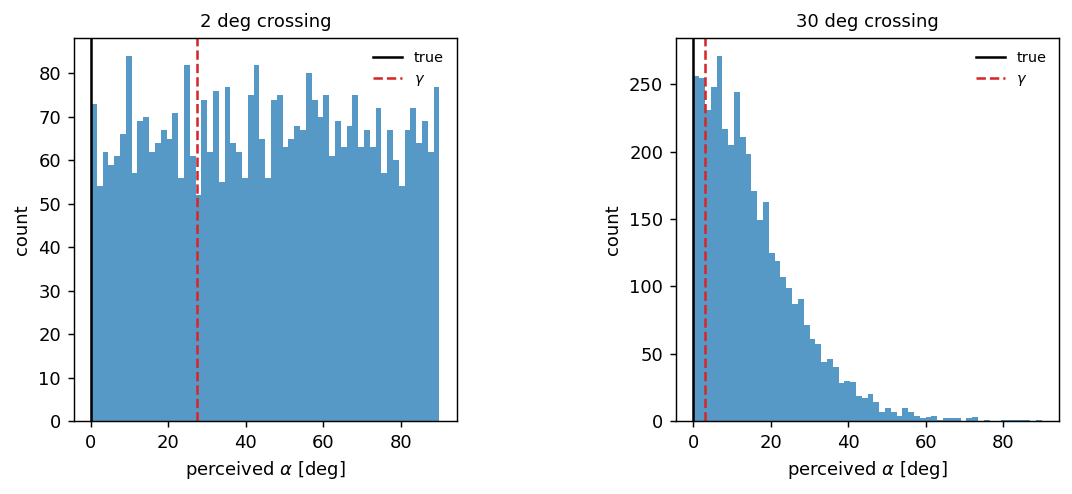

In [8]:
def perceive(own, intr, n, seed=0):
    """n independent fixes of the pair, through the simulator's own GNSS model."""
    nav = GnssNavigation()
    state = nav.initial_state()
    rng = np.random.default_rng(seed)
    out = []
    for _ in range(n):
        out.append((nav.measure(state, own, 0.0, rng).state,
                    nav.measure(state, intr, 0.0, rng).state))
    return out


fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.9))
for ax, (label, (o, i)) in zip(axes, (("2 deg", (own2, intr2)), ("30 deg", (own30, intr30)))):
    rel_true, v_true, *_, alpha_true = geometry(o, i)
    gamma = math.asin(RPZ * MARGIN / rel_true.dist)
    alphas = [math.degrees(geometry(of, if_)[5]) for of, if_ in perceive(o, i, 4000)]
    ax.hist(alphas, bins=60, color=BLUE, alpha=0.75)
    ax.axvline(math.degrees(alpha_true), color="k", lw=1.4, label="true")
    ax.axvline(math.degrees(gamma), color=RED, ls="--", lw=1.4, label=r"$\gamma$")
    ax.set_xlabel(r"perceived $\alpha$ [deg]")
    ax.set_ylabel("count")
    ax.set_title(f"{label} crossing", fontsize=10)
    ax.legend(frameon=False, fontsize=8)
    ax.set_box_aspect(1)
fig.tight_layout()

The true $\alpha$ is ~0 in both panels. At 30° the perceived value clusters near it. At 2° it is
spread across the whole range, and a large share of draws sit **beyond $\gamma$** — the aircraft
perceives itself to be already clear when it is not.

**What MVP does with this:** nothing. MVP takes the perceived $\alpha$ at face value and rotates by
$\gamma-\tilde\alpha$. When $\tilde\alpha$ is a large over-estimate, MVP barely manoeuvres.

---
## Step 5 — from the angle's uncertainty to the margin's

Define the **angular margin** $m=\alpha-\gamma$. Clearing the zone is $m>0$. Both terms are
computed from noisy states, so both carry error. Decompose an isotropic position error into its
radial and tangential parts — they are independent:

- tangential $\to$ the line of sight swings: $\sigma_r/\lvert\mathbf r\rvert$
- radial $\to$ the range is wrong, so $\gamma=\arcsin(R/\lvert\mathbf r\rvert)$ is wrong:
  $\tan\gamma\;\sigma_r/\lvert\mathbf r\rvert$
- and the velocity term from step 4: $\sigma_v/\lvert\mathbf v\rvert$

Adding in quadrature, the two position pieces collapse neatly:

$$ \boxed{\;\sigma_m^2=\left(\frac{\sigma_v}{\lvert\mathbf v\rvert}\right)^2+\left(\frac{\sigma_r}{\lvert\mathbf r\rvert\cos\gamma}\right)^2\;} $$

Let us check the closed form against a Monte Carlo of the perceived margin.

In [9]:
def margin_spread(dpsi, dcpa, pos_ci95, vel_ci95, n=4000, seed=1):
    """Closed-form sigma_m, the measured spread of the perceived margin, and the headroom.

    `headroom` is the true alpha in units of sigma_m: how far the angle sits from its own lower
    bound of zero. The linearisation is a statement about a *free* Gaussian, so it can only be
    checked where the angle has room to be one.
    """
    o, i = encounter(dpsi, pos_ci95=pos_ci95, vel_ci95=vel_ci95, dcpa=dcpa)
    rel, v_mag, _, _, _, alpha_true = geometry(o, i)
    sr, sv = relative_sigmas(o, i)
    gamma = math.asin(min(RPZ * MARGIN / rel.dist, 1.0))
    closed = math.hypot(sv / v_mag, sr / (rel.dist * math.cos(gamma)))
    margins = []
    for of, if_ in perceive(o, i, n, seed=seed):
        rel_p, _, _, _, _, alpha_p = geometry(of, if_)
        margins.append(alpha_p - math.asin(min(RPZ * MARGIN / rel_p.dist, 1.0)))
    return closed, float(np.std(margins)), alpha_true / closed


print("30 deg crossing, dcpa 300 m, shrinking the declared uncertainty")
print(f"{'pos, vel declared':>20} {'headroom':>9} {'closed form':>12} {'Monte Carlo':>12} {'ratio':>7}")
for s in (0.02, 0.1, 0.3, 1.0):
    closed, mc, head = margin_spread(30.0, 300.0, POS_CI95 * s, VEL_CI95 * s)
    print(f"{f'{POS_CI95*s:5.2f} m, {VEL_CI95*s:4.2f} m/s':>20} {head:9.1f} "
          f"{closed:12.5f} {mc:12.5f} {mc/closed:7.2f}")

print("\nthe campaign's own conditions (10 m, 3 m/s), where the angle is cramped")
for dpsi, dcpa in ((30.0, 0.0), (2.0, 0.0)):
    closed, mc, head = margin_spread(dpsi, dcpa, POS_CI95, VEL_CI95)
    print(f"{f'{dpsi:g} deg, dcpa {dcpa:g} m':>20} {head:9.1f} "
          f"{closed:12.5f} {mc:12.5f} {mc/closed:7.2f}")

30 deg crossing, dcpa 300 m, shrinking the declared uncertainty
   pos, vel declared  headroom  closed form  Monte Carlo   ratio
    0.20 m, 0.06 m/s      46.6      0.00651      0.00655    1.01
    1.00 m, 0.30 m/s       9.3      0.03255      0.03279    1.01
    3.00 m, 0.90 m/s       3.1      0.09765      0.09844    1.01
   10.00 m, 3.00 m/s       0.9      0.32549      0.27295    0.84

the campaign's own conditions (10 m, 3 m/s), where the angle is cramped
    30 deg, dcpa 0 m       0.0      0.32549      0.22188    0.68


     2 deg, dcpa 0 m       0.0      4.82665      0.45592    0.09


The top block is the check. Shrink the declared uncertainty and the ratio climbs to 1: the closed
form is exact in the limit it was derived for. `headroom` is the true $\alpha$ measured in units of
$\sigma_m$ — how much room the angle has above its own lower bound of zero — and the agreement
tracks it directly.

The bottom block is the campaign. **At real GNSS accuracy and a real conflict geometry the headroom
is well under one**, so the measured spread is far smaller than the formula. Two effects, both
worth naming:

- The angle is **bounded** to $[0,\pi/2]$; a 4.83 rad spread cannot fit in an interval $\pi/2$ wide.
- At `dcpa` = 0 the true $\alpha$ is *zero*, the boundary itself, so the perceived $\alpha$ is
  **folded** — it can only come out positive. A folded normal has spread
  $\sigma\sqrt{1-2/\pi}\approx0.6\sigma$, which is most of the remaining gap at 30°.

So $\sigma_m$ is an over-estimate exactly where the geometry is tight. That is the **safe**
direction to be wrong in — the rule asks for more margin than the linear model strictly justifies —
and it is worth being explicit that this is a conservatism, not an accuracy.

The folding has a second consequence that lands on MVP rather than on us. Because the perceived miss
distance is always an over-estimate, by $\sigma_r\sqrt{2/\pi}$ on average, MVP credits itself with
clearance it does not have and lands *short* of its target systematically. That is why MVP's
realised failure rate under position noise comes out above one half rather than at it.

Carry one thing forward into step 7: a spread that overflows the angle is merely pessimistic, but
the same overflow written on the **distance** becomes a target no velocity can reach.

**What MVP does here:** nothing again. MVP has no $\sigma$ anywhere in it.

---
## Step 6 — the manoeuvre changes its own uncertainty

Here is the part that makes RMVP more than a bigger buffer.

Step 3 established that the perpendicular step **lengthens** the relative velocity,
$\lvert\mathbf v'\rvert=\lvert\mathbf v\rvert/\cos\theta$. Step 4 established that the angular noise
is $\sigma_v/\lvert\mathbf v\rvert$. Put them together:

$$ \boxed{\;\sigma_m(\theta)^2=\left(\frac{\sigma_v\cos\theta}{\lvert\mathbf v\rvert}\right)^2+\left(\frac{\sigma_r}{\lvert\mathbf r\rvert\cos\gamma}\right)^2\;} $$

**Turning harder does not only move you further away, it makes the outcome better known.** The
position term carries no $\theta$: no velocity change can re-measure where the aircraft are, so it
is the floor.

**What MVP does here:** MVP's step lengthens $\mathbf v$ too — it gets this benefit by accident. It
simply has no way to know it, or to ask for more of it.

pre-manoeuvre   : |v'| =  0.359 m/s, sigma_m =  4.827 rad
after MVP       : |v'| =  0.404 m/s, sigma_m =  4.293 rad


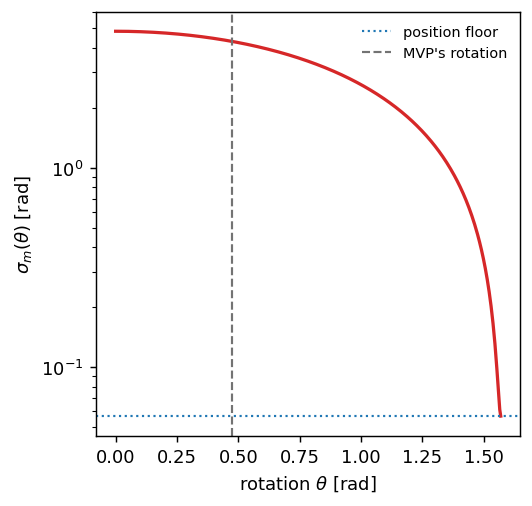

In [10]:
rel, v_mag, t_cpa, d_mvp, cross, alpha = geometry(own2, intr2)
alpha = math.asin(max(d_mvp, 0.1) / rel.dist)
gamma = math.asin(RPZ * MARGIN / rel.dist)
sigma_phi = sigma_v / v_mag
sigma_los = sigma_r / (rel.dist * math.cos(gamma))

theta_mvp = gamma - alpha
print(f"pre-manoeuvre   : |v'| = {v_mag:6.3f} m/s, sigma_m = {angular_sigma(0.0, sigma_phi, sigma_los):6.3f} rad")
print(f"after MVP       : |v'| = {v_mag/math.cos(theta_mvp):6.3f} m/s, "
      f"sigma_m = {angular_sigma(theta_mvp, sigma_phi, sigma_los):6.3f} rad")

fig, ax = plt.subplots(figsize=(4.6, 4.0))
th = np.linspace(0, 0.5 * math.pi - alpha, 400)
ax.plot(th, [angular_sigma(t, sigma_phi, sigma_los) for t in th], color=RED, lw=1.8)
ax.axhline(sigma_los, color=BLUE, ls=":", lw=1.2, label="position floor")
ax.axvline(theta_mvp, color=GREY, ls="--", lw=1.2, label="MVP's rotation")
ax.set_yscale("log")
ax.set_xlabel(r"rotation $\theta$ [rad]")
ax.set_ylabel(r"$\sigma_m(\theta)$ [rad]")
ax.legend(frameon=False, fontsize=8)
ax.set_box_aspect(1)
fig.tight_layout()

---
## Step 7 — the rule, and why it is a fixed point

We want the manoeuvre to clear the zone with probability $c$, not on average. To first order the
margin is Gaussian, so that is a statement about its mean:

$$ \boxed{\;\alpha+\theta-\gamma\;\ge\;k\,\sigma_m(\theta),\qquad k=\Phi^{-1}(c)\;} $$

and RMVP takes the **smallest** $\theta\ge0$ that satisfies it.

Set $k=0$ and it collapses to $\theta=\gamma-\alpha$, which is MVP exactly (step 3). **MVP is the
50%-confidence member of this family** — it aims at the median miss distance, and half the
realisations fall short of it.

For $k>0$ both sides depend on $\theta$, so there is nothing to look up: the requirement *falls* as
the manoeuvre grows, and the answer is where the two curves cross.

In [11]:
k = RMVP(confidence=0.95).k
required = lambda t: gamma + k * angular_sigma(t, sigma_phi, sigma_los)
supplied = lambda t: alpha + t

theta_star = rotation(alpha, gamma, k, sigma_phi, sigma_los)
one_shot = gamma - alpha + k * angular_sigma(0.0, sigma_phi, sigma_los)

print(f"k = Phi^-1(0.95)                 = {k:.4f}")
print(f"MVP's rotation (k = 0)           = {theta_mvp:.4f} rad = {math.degrees(theta_mvp):5.1f} deg")
print(f"RMVP's rotation (fixed point)    = {theta_star:.4f} rad = {math.degrees(theta_star):5.1f} deg")
print(f"residual at the root             = {supplied(theta_star) - required(theta_star):.2e} rad")
print()
print(f"if we did NOT iterate, and just used sigma_m(0) once:")
print(f"   demanded rotation             = {one_shot:.3f} rad = {math.degrees(one_shot):5.0f} deg")
print(f"   ... but the largest useful rotation is {0.5*math.pi - alpha:.3f} rad "
      f"({math.degrees(0.5*math.pi - alpha):.0f} deg). No such manoeuvre exists.")

k = Phi^-1(0.95)                 = 1.6449
MVP's rotation (k = 0)           = 0.4748 rad =  27.2 deg
RMVP's rotation (fixed point)    = 1.4484 rad =  83.0 deg
residual at the root             = 3.02e-13 rad

if we did NOT iterate, and just used sigma_m(0) once:
   demanded rotation             = 8.414 rad =   482 deg
   ... but the largest useful rotation is 1.570 rad (90 deg). No such manoeuvre exists.


That last block is the argument against calling this "an adaptive margin". A margin computed
**once** from the current state demands a 482° turn here and has no solution. The self-consistent
answer is 83°, and it exists because rotating pays down the very noise that made the demand large.

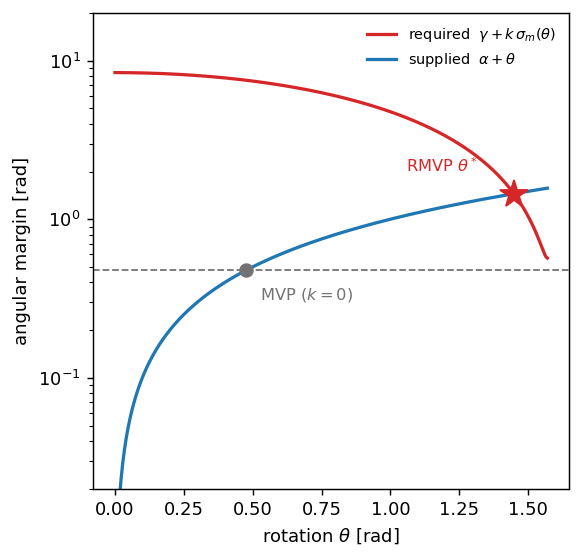

In [12]:
fig, ax = plt.subplots(figsize=(5.0, 4.4))
th = np.linspace(0, 0.5 * math.pi - alpha, 500)
ax.plot(th, [required(t) for t in th], color=RED, lw=1.8,
        label=r"required  $\gamma + k\,\sigma_m(\theta)$")
ax.plot(th, [supplied(t) for t in th], color=BLUE, lw=1.8, label=r"supplied  $\alpha + \theta$")
ax.axhline(gamma, color=GREY, ls="--", lw=1.0)
ax.plot([theta_mvp], [gamma], "o", ms=7, color=GREY)
ax.plot([theta_star], [supplied(theta_star)], "*", ms=16, color=RED)
ax.annotate("MVP ($k=0$)", (theta_mvp, gamma), textcoords="offset points",
            xytext=(8, -16), fontsize=9, color=GREY)
ax.annotate(r"RMVP $\theta^*$", (theta_star, supplied(theta_star)),
            textcoords="offset points", xytext=(-60, 12), fontsize=9, color=RED)
ax.set_yscale("log")
ax.set_ylim(0.02, 20)
ax.set_xlabel(r"rotation $\theta$ [rad]")
ax.set_ylabel("angular margin [rad]")
ax.legend(frameon=False, fontsize=8, loc="upper right")
ax.set_box_aspect(1)
fig.tight_layout()

The red curve is strictly decreasing and the blue one strictly increasing, so the crossing is unique
and a solver cannot get lost. `rotation()` walks it with Newton kept inside a bracket — about five
iterations. Watch it converge:

In [13]:
def trace(alpha, gamma, k, sigma_phi, sigma_los, tol=1e-12, iters=40):
    """rotation(), instrumented, so the iterates are visible."""
    f = lambda t: alpha + t - gamma - k * angular_sigma(t, sigma_phi, sigma_los)
    lo, hi = 0.0, 0.5 * math.pi - alpha
    t = 0.5 * (lo + hi)
    rows = []
    for n in range(iters):
        val = f(t)
        rows.append((n, t, val))
        if abs(val) < tol:
            break
        lo, hi = (t, hi) if val < 0 else (lo, t)
        s = angular_sigma(t, sigma_phi, sigma_los)
        slope = 1.0 + k * sigma_phi**2 * math.cos(t) * math.sin(t) / s
        step = t - val / slope
        t = step if lo < step < hi else 0.5 * (lo + hi)
    return rows


print(f"{'iter':>4} {'theta [rad]':>13} {'residual':>13}")
for n, t, val in trace(alpha, gamma, k, sigma_phi, sigma_los):
    print(f"{n:4d} {t:13.9f} {val:13.2e}")

iter   theta [rad]      residual
   0   0.784962030     -5.31e+00
   1   1.177443045     -2.34e+00
   2   1.458579924      8.99e-02
   3   1.448413512      1.12e-05
   4   1.448412250      3.02e-13


---
## Step 8 — the code, against MVP's

Everything above amounts to a small edit. Here are the two `_pairwise_dv` functions, diffed.

In [14]:
import difflib
import inspect

import opencdarr.cr.mvp as mvp_mod
import rmvp as rmvp_mod

a = inspect.getsource(mvp_mod._pairwise_dv).split("\n")
b = inspect.getsource(rmvp_mod._pairwise_dv).split("\n")
for line in difflib.unified_diff(a, b, "opencdarr/cr/mvp.py", "robust-mvp/rmvp.py", lineterm="", n=2):
    print(line)

--- opencdarr/cr/mvp.py
+++ robust-mvp/rmvp.py
@@ -1,10 +1,19 @@
-def _pairwise_dv(own: AircraftState, intr: AircraftState, rpz_eff: float) -> tuple[float, float]:
+def _pairwise_dv(
+    own: AircraftState,
+    intr: AircraftState,
+    rpz_eff: float,
+    k: float,
+    velocity_uncertainty: Literal["both", "intruder"],
+) -> tuple[float, float]:
     """The velocity change ``dv`` to **subtract** from ``own``'s velocity to clear this one pair.
 
-    The MVP avoidance vector for a single directed pair (``own`` steers away from the CPA point):
-    the ownship's new velocity is ``v_own − dv``. ``(0, 0)`` when there is no relative motion
-    (nothing to resolve for this pair). Isolated as a pairwise primitive so the N-aircraft resolve
-    is the **sum** of these (ADR 0004 / Phase 6): MVP is a potential-field method, so the pairwise
-    avoidance vectors superpose.
+    ``(0, 0)`` when there is no relative motion. Isolated as a pairwise primitive because the
+    N-aircraft resolve

The shared parts are the CPA algebra, the `_BIAS_EPS` head-on tie-break, and the final
`scale * (cx, cy)` step along $\hat{\mathbf c}$. What changed is the middle: MVP's gain-and-erratum
block becomes $\alpha$, $\gamma$, the two sigmas, and one call to `rotation`.

Because the tie-break is kept verbatim, `confidence = 0.5` is MVP — which is what makes this a
controlled comparison rather than a different algorithm.

In [15]:
print(f"{'dpsi':>6} {'MVP':>10} {'RMVP c=0.50':>13} {'RMVP c=0.95':>13}")
for dpsi in (2.0, 10.0, 30.0, 90.0):
    o, i = encounter(dpsi)
    m = mvp_step(o, i)

    def step(res):
        ve, vn = velocity_enu(o)
        ne, nn = res.resolve(o, [i], RPZ).target_velocity
        return math.hypot(ne - ve, nn - vn)

    print(f"{dpsi:6.0f} {m:10.4f} {step(RMVP(margin=MARGIN, confidence=0.5)):13.4f} "
          f"{step(RMVP(margin=MARGIN, confidence=0.95)):13.4f}")

  dpsi        MVP   RMVP c=0.50   RMVP c=0.95
     2     0.1846        0.1846        2.9198
    10     0.2546        0.2546        2.7939
    30     0.2771        0.2771        3.0305
    90     0.2857        0.2857        3.1203


---
## Step 9 — does it work, and where does it not?

The test that counts: perceive the encounter, resolve, then score the manoeuvre against the **true**
states. If the design confidence means anything, about 95% of draws should clear the protected zone.

In [16]:
def delivered(resolver, own, intr, n=4000, seed=7):
    """Fraction of noisy perceptions whose commanded velocity truly clears rpz, and the mean step."""
    nav = GnssNavigation()
    st = nav.initial_state()
    rng = np.random.default_rng(seed)
    ve_t, vn_t = velocity_enu(own)
    cleared, total = 0, 0.0
    for _ in range(n):
        of = nav.measure(st, own, 0.0, rng).state
        if_ = nav.measure(st, intr, 0.0, rng).state
        ce, cn = resolver.resolve(of, [if_], RPZ).target_velocity
        total += math.hypot(ce - ve_t, cn - vn_t)
        flown = AircraftState(id="OWN", lat=own.lat, lon=own.lon,
                              trk=math.degrees(math.atan2(ce, cn)) % 360.0,
                              gs=math.hypot(ce, cn))
        t = relative_enu(flown, intr)
        vm = math.hypot(t.vx, t.vy)
        cleared += abs(t.rx * t.vy - t.ry * t.vx) / vm > RPZ
    return cleared / n, total / n


print(f"{'':>8} {'MVP':>22} {'RMVP 0.95':>22}")
print(f"{'dpsi':>8} {'P(clear)':>11}{'|dv|':>11} {'P(clear)':>11}{'|dv|':>11}")
for dpsi in (2.0, 5.0, 10.0, 30.0, 90.0):
    o, i = encounter(dpsi)
    pm, dm = delivered(MVP(margin=MARGIN), o, i)
    pr, dr = delivered(RMVP(margin=MARGIN, confidence=0.95), o, i)
    print(f"{dpsi:8.0f} {pm:11.3f}{dm:11.2f} {pr:11.3f}{dr:11.2f}")

                            MVP              RMVP 0.95
    dpsi    P(clear)       |dv|    P(clear)       |dv|


       2       0.581       2.07       0.857       2.45


       5       0.613       2.47       0.943       2.30


      10       0.676       2.51       0.970       2.38


      30       0.789       1.58       0.990       2.71


      90       0.799       1.45       0.991       2.77


MVP sits near one half everywhere, which is what step 7 predicted: it aims at the *median*.

RMVP reaches its 0.95 target from about 10° upward. At 2° and 5° it falls short. That is a real
limitation, and it is worth being precise about why, because the obvious explanation is wrong.

It is **not** mainly the Gaussian approximation of step 5. It is that at 2° the confidence is often
**unattainable by any rotation**: the direction of the relative velocity is so poorly known that
even turning to fully perpendicular does not concentrate it enough. Let us measure the ceiling.

In [17]:
from opencdarr.crr.probabilistic_ftr import _p_offset_gt

from rmvp_exact import _iso   # the exact projected-normal probability, no Gaussian assumption


def ceiling(own, intr, n=800, seed=5):
    """Best P(clear) any rotation can reach, per perceived state, and how often 0.95 is out of reach."""
    best = []
    for of, if_ in perceive(own, intr, n, seed=seed):
        rel_p, v_p, _, d_p, _, _ = geometry(of, if_)
        d_p = max(d_p, 0.1)
        a_p = math.asin(min(d_p / rel_p.dist, 1.0))
        sr, sv = relative_sigmas(of, if_)
        cx, cy = rel_p.rx + rel_p.vx * (-(rel_p.rx*rel_p.vx + rel_p.ry*rel_p.vy)/v_p**2), \
                 rel_p.ry + rel_p.vy * (-(rel_p.rx*rel_p.vx + rel_p.ry*rel_p.vy)/v_p**2)
        norm = math.hypot(cx, cy) or 1.0
        ce, cn = cx / norm, cy / norm
        a = v_p * math.tan(0.5 * math.pi - a_p)
        mu_v = np.array([rel_p.vx + a * ce, rel_p.vy + a * cn])
        best.append(_p_offset_gt(RPZ * MARGIN, np.array([rel_p.rx, rel_p.ry]),
                                 _iso(sr), mu_v, _iso(sv), 128))
    best = np.array(best)
    return float(np.median(best)), float(np.mean(best < 0.95))


for dpsi in (2.0, 5.0, 30.0):
    med, share = ceiling(*encounter(dpsi))
    print(f"{dpsi:5.0f} deg: median best-achievable P = {med:.3f};  "
          f"0.95 unattainable in {share:5.1%} of perceived geometries")

    2 deg: median best-achievable P = 0.880;  0.95 unattainable in 62.0% of perceived geometries
    5 deg: median best-achievable P = 0.973;  0.95 unattainable in 42.6% of perceived geometries


   30 deg: median best-achievable P = 1.000;  0.95 unattainable in  0.0% of perceived geometries


At 2° the ceiling sits near the delivered number, and 0.95 is out of reach in most decisions. No
choice of quantile fixes that — it is a statement about what a **rotation** can buy, not about how
the probability is approximated. (Running the same rule with the exact projected-normal quantile
instead of the Gaussian one moves 2° from 0.848 to 0.855, and fixes an *over*-delivery at 30°:
0.988 down to 0.957 while commanding 20% less. `rmvp_exact.py` is that experiment.)

Carried all the way through to a rare-event campaign, the three rules give, at 2° with
`ci95` (10 m, 3 m/s) and 600 particles x 8 replications:

| resolver | P(loss of separation) | 95% interval |
|---|---|---|
| MVP | 1.112e-03 | [8.28e-04, 1.34e-03] |
| RMVP 0.95 | 7.614e-05 | [5.86e-05, 9.09e-05] |
| RMVPExact 0.95 | 6.083e-05 | [3.79e-05, 7.52e-05] |

A 15x gap between MVP and RMVP, with disjoint intervals. Between the Gaussian and the exact
quantile the intervals overlap: at this geometry the extra machinery does not buy measurable
safety, because the closed loop re-decides every 0.2 s and washes out a one-step difference.

One idea this notebook has deliberately not used: every rule here steps **perpendicular** to
$\mathbf v$. A step *parallel* to it raises $\lvert\mathbf v'\rvert$ — and therefore the angular
signal-to-noise ratio — without changing the nominal miss distance at all. The MVP family throws
that direction away as useless. Under velocity uncertainty it is not.

---
## What to take away

1. The miss distance depends only on the **direction** of the relative velocity, so the problem is
   one-dimensional and the velocity obstacle never needs constructing.
2. MVP is the **exact rotation** $\gamma-\alpha$ onto the obstacle's leg.
3. Velocity uncertainty is an **angular** SNR, $\sigma_v/\lvert\mathbf v\rvert$ — 4.83 rad at a 2°
   crossing between two 20 kt aircraft.
4. The manoeuvre **shrinks its own uncertainty**, because a perpendicular step lengthens
   $\mathbf v$. That coupling is what makes the rule a fixed point and not a lookup.
5. MVP is the 50%-confidence member of the family; $k=0$ recovers it exactly.
6. It works from about 10° upward. At 2° the requested confidence is usually **unavailable**, and
   the honest reading of such a cell is "not achievable here", not "95% delivered".

Where to go next:

- `vault/derivations/robust-mvp-resolution.md` — the full derivation, the "is this only an adaptive
  margin?" argument, and every measured result.
- `robust-mvp/rmvp.py` — the implementation, 90 lines of it the same as MVP's.
- `robust-mvp/verify_rmvp.py` — the claims above, checked one at a time.
- `robust-mvp/ips_run.py` — the rare-event campaign that turns these single-shot numbers into
  P(loss of separation).